# 04 DPO Review

Purpose: launch the Stage 2 DPO run from the Drive-backed source tree, inspect the saved loss and reward traces, evaluate SFT vs DPO on the held-out manifest, and produce one consolidated baseline vs SFT vs DPO report.

Preconditions:
- Run `00_colab_setup.ipynb` first.
- Run `02_sft_review.ipynb` at least once so the SFT manifest and adapter metadata exist.
- If you need fresh preference pairs, run `03_preference_pair_audit.ipynb` before this notebook.


In [ ]:
from pathlib import Path

SOURCE_ROOT = Path('/content/drive/MyDrive/json-ft-source')
RUNTIME_ROOT = Path('/content/drive/MyDrive/json-ft-runs')

PROFILE = 'full'
SFT_RUN_NAME = 'sft-full-colab'
PREFERENCE_RUN_NAME = 'pref-full-colab'
DPO_RUN_NAME = 'dpo-full-colab'
DPO_TRAIN_BATCH_SIZE = 8
DPO_EVAL_BATCH_SIZE = 8
DPO_GRADIENT_ACCUMULATION_STEPS = 8
DPO_TRAIN_SAMPLE_PERCENT = 1.0
DPO_EVAL_SAMPLE_PERCENT = 1.0
DPO_SAMPLE_SEED = 17
SFT_EVAL_RUN_NAME = f'{SFT_RUN_NAME}_eval'
DPO_EVAL_RUN_NAME = f'{DPO_RUN_NAME}_eval'
COMPARISON_RUN_NAME = f'{DPO_RUN_NAME}_comparison'

BASELINE_RUN_NAME = 'baseline-qwen2.5-1.5b'
SFT_MANIFEST_NAME = f'{SFT_RUN_NAME}_adapter_manifest.json'

PREFERENCE_MANIFEST = RUNTIME_ROOT / 'persistent' / 'preferences' / PREFERENCE_RUN_NAME / f'{PREFERENCE_RUN_NAME}_dpo_pairs.jsonl'
SFT_MANIFEST = SOURCE_ROOT / 'artifacts' / 'checkpoints' / SFT_MANIFEST_NAME
DPO_MANIFEST = SOURCE_ROOT / 'artifacts' / 'checkpoints' / f'{DPO_RUN_NAME}_dpo_manifest.json'

EVAL_MANIFEST = SOURCE_ROOT / 'data' / 'manifests' / 'support_tickets_eval_manifest.jsonl'
BASELINE_METRICS = SOURCE_ROOT / 'artifacts' / 'metrics' / f'{BASELINE_RUN_NAME}_metrics.json'
BASELINE_PREDICTIONS = SOURCE_ROOT / 'artifacts' / 'reports' / f'{BASELINE_RUN_NAME}_predictions.jsonl'

SOURCE_ROOT, RUNTIME_ROOT, PREFERENCE_MANIFEST, SFT_MANIFEST


(PosixPath('/content/drive/MyDrive/json-ft-source'),
 PosixPath('/content/drive/MyDrive/json-ft-runs'),
 PosixPath('/content/drive/MyDrive/json-ft-runs/persistent/preferences/pref-full-colab/pref-full-colab_dpo_pairs.jsonl'),
 PosixPath('/content/drive/MyDrive/json-ft-source/artifacts/checkpoints/sft-full-colab_adapter_manifest.json'))

In [2]:
required_paths = [
    SOURCE_ROOT / 'scripts' / 'train_dpo.py',
    SOURCE_ROOT / 'scripts' / 'eval_model.py',
    SOURCE_ROOT / 'scripts' / 'compare_stages.py',
    SOURCE_ROOT / 'configs' / 'dpo.yaml',
    SOURCE_ROOT / 'configs' / 'eval.yaml',
    EVAL_MANIFEST,
    PREFERENCE_MANIFEST,
    SFT_MANIFEST,
    BASELINE_METRICS,
    BASELINE_PREDICTIONS,
]

missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError('Missing required DPO inputs:\n' + '\n'.join(str(path) for path in missing))

print('All DPO review prerequisites are present.')


All DPO review prerequisites are present.


In [3]:
command = [
    'python',
    str(SOURCE_ROOT / 'scripts' / 'train_dpo.py'),
    '--config',
    str(SOURCE_ROOT / 'configs' / 'dpo.yaml'),
    '--profile',
    PROFILE,
    '--run-name',
    DPO_RUN_NAME,
    '--runtime-root',
    str(RUNTIME_ROOT),
    '--preference-manifest',
    str(PREFERENCE_MANIFEST),
    '--source-sft-manifest',
    str(SFT_MANIFEST),
    '--per-device-train-batch-size',
    str(DPO_TRAIN_BATCH_SIZE),
    '--per-device-eval-batch-size',
    str(DPO_EVAL_BATCH_SIZE),
    '--gradient-accumulation-steps',
    str(DPO_GRADIENT_ACCUMULATION_STEPS),
    '--train-sample-percent',
    str(DPO_TRAIN_SAMPLE_PERCENT),
    '--eval-sample-percent',
    str(DPO_EVAL_SAMPLE_PERCENT),
    '--sample-seed',
    str(DPO_SAMPLE_SEED),
    '--mirror-metrics-to-repo',
    '--mirror-plots-to-repo',
    '--mirror-checkpoint-manifest-to-repo',
    '--promote-latest',
]

print('Running command:')
print(' '.join(command))


Running command:
python /content/drive/MyDrive/json-ft-source/scripts/train_dpo.py --config /content/drive/MyDrive/json-ft-source/configs/dpo.yaml --profile full --run-name dpo-full-colab --runtime-root /content/drive/MyDrive/json-ft-runs --preference-manifest /content/drive/MyDrive/json-ft-runs/persistent/preferences/pref-full-colab/pref-full-colab_dpo_pairs.jsonl --source-sft-manifest /content/drive/MyDrive/json-ft-source/artifacts/checkpoints/sft-full-colab_adapter_manifest.json --per-device-train-batch-size 8 --per-device-eval-batch-size 8 --gradient-accumulation-steps 8 --train-sample-percent 1.0 --eval-sample-percent 1.0 --sample-seed 17 --mirror-metrics-to-repo --mirror-plots-to-repo --mirror-checkpoint-manifest-to-repo --promote-latest


In [4]:
!python {SOURCE_ROOT / 'scripts' / 'train_dpo.py'} \
    --config {SOURCE_ROOT / 'configs' / 'dpo.yaml'} \
    --profile {PROFILE} \
    --run-name {DPO_RUN_NAME} \
    --runtime-root {RUNTIME_ROOT} \
    --preference-manifest {PREFERENCE_MANIFEST} \
    --source-sft-manifest {SFT_MANIFEST} \
    --per-device-train-batch-size {DPO_TRAIN_BATCH_SIZE} \
    --per-device-eval-batch-size {DPO_EVAL_BATCH_SIZE} \
    --gradient-accumulation-steps {DPO_GRADIENT_ACCUMULATION_STEPS} \
    --train-sample-percent {DPO_TRAIN_SAMPLE_PERCENT} \
    --eval-sample-percent {DPO_EVAL_SAMPLE_PERCENT} \
    --sample-seed {DPO_SAMPLE_SEED} \
    --mirror-metrics-to-repo \
    --mirror-plots-to-repo \
    --mirror-checkpoint-manifest-to-repo \
    --promote-latest


DPO training
Config: /content/drive/MyDrive/json-ft-source/configs/dpo.yaml
Profile: full
Run name: dpo-full-colab
Base model: Qwen/Qwen2.5-1.5B-Instruct
Policy init: Qwen/Qwen2.5-1.5B-Instruct
Reference strategy: adapter
Source adapter path: /content/drive/MyDrive/json-ft-runs/persistent/checkpoints/sft/sft-full-colab/adapter
Preference manifest: /content/drive/MyDrive/json-ft-runs/persistent/preferences/pref-full-colab/pref-full-colab_dpo_pairs.jsonl
Eval preference manifest: <none>
Dataset build summary: /content/drive/MyDrive/json-ft-source/data/manifests/support_tickets_dataset_build_summary.json
Dataset composition summary: /content/drive/MyDrive/json-ft-source/artifacts/metrics/support_tickets_dataset_composition.json
Pair quality gates: {'minimum_score_gap': 0.4, 'max_similarity_ratio': 0.96, 'reject_same_failure_mode': True, 'require_chosen_schema_valid': True, 'minimum_candidate_count_after_dedup': 2}
Train rows: 2858
Eval rows: 0
Train subset: {'original_row_count': 2858, 's

In [3]:
import json

dpo_summary_path = RUNTIME_ROOT / 'persistent' / 'metrics' / f'{DPO_RUN_NAME}_dpo_summary.json'
dpo_history_path = RUNTIME_ROOT / 'persistent' / 'metrics' / f'{DPO_RUN_NAME}_dpo_history.json'

dpo_summary = json.loads(dpo_summary_path.read_text(encoding='utf-8'))
dpo_history = json.loads(dpo_history_path.read_text(encoding='utf-8'))

dpo_summary


{'adapter_path': '/content/drive/MyDrive/json-ft-runs/persistent/checkpoints/dpo/dpo-full-colab/adapter',
 'base_model': 'Qwen/Qwen2.5-1.5B-Instruct',
 'checkpoint_root': '/content/drive/MyDrive/json-ft-runs/persistent/checkpoints/dpo/dpo-full-colab',
 'config_path': '/content/drive/MyDrive/json-ft-source/configs/dpo.yaml',
 'data_pipeline': {'build_summary': {'leakage_checks': {'eval_root_count': 12450,
    'is_lineage_clean': True,
    'leaked_train_row_count': 0,
    'leaked_train_rows': []},
   'nullable_field_null_rates': {'customer.account_id': 1.0,
    'customer.name': 0.9714,
    'customer.plan_tier': 0.3018},
   'profile': 'full',
   'schema': {'name': 'support_ticket_extraction', 'version': '1.0.0'},
   'source_counts': {'console_ai_it_helpdesk_synthetic_tickets': 500,
    'prady06_customer_support_tickets': 61763,
    'synthetic_hardening_v1': 21341,
    'synthetic_support_tickets_v1': 7},
   'source_group_counts': {'domain_task_data': 62270,
    'synthetic_augmentation_data

training_loss: /content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_loss_curve.png


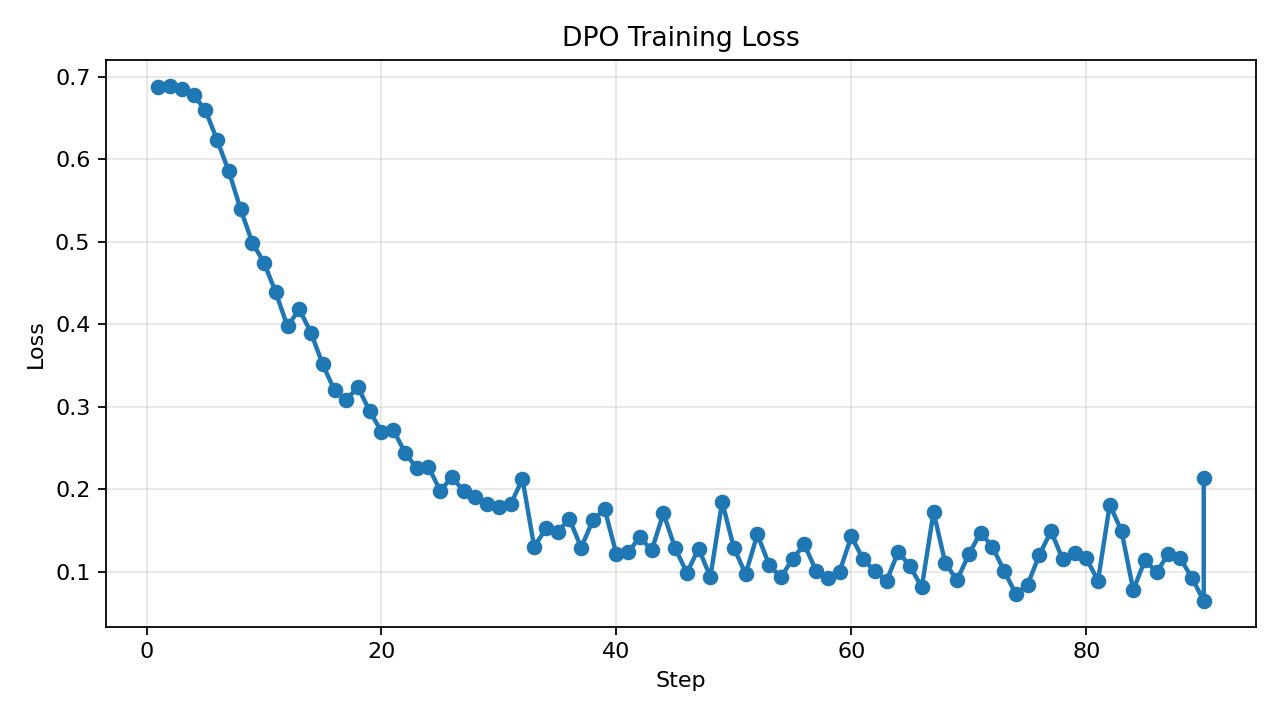

rewards_accuracies: /content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_rewards_accuracies_curve.png


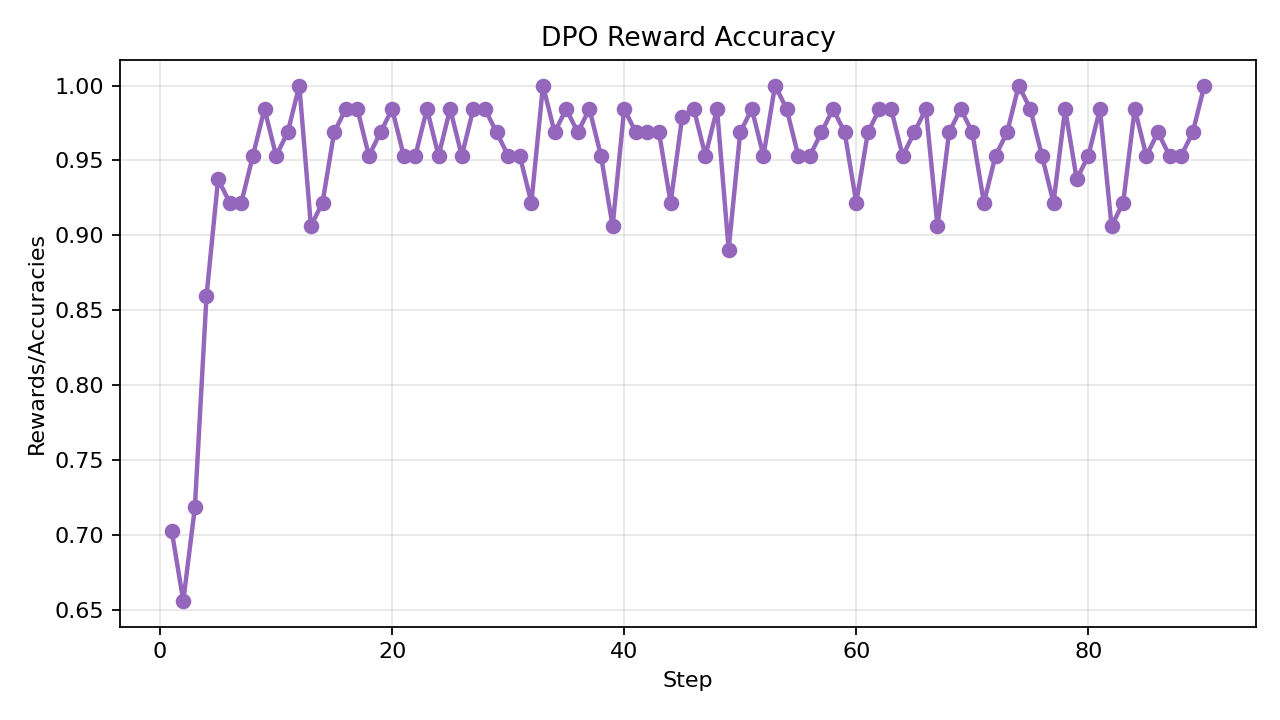

rewards_chosen: /content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_rewards_chosen_curve.png


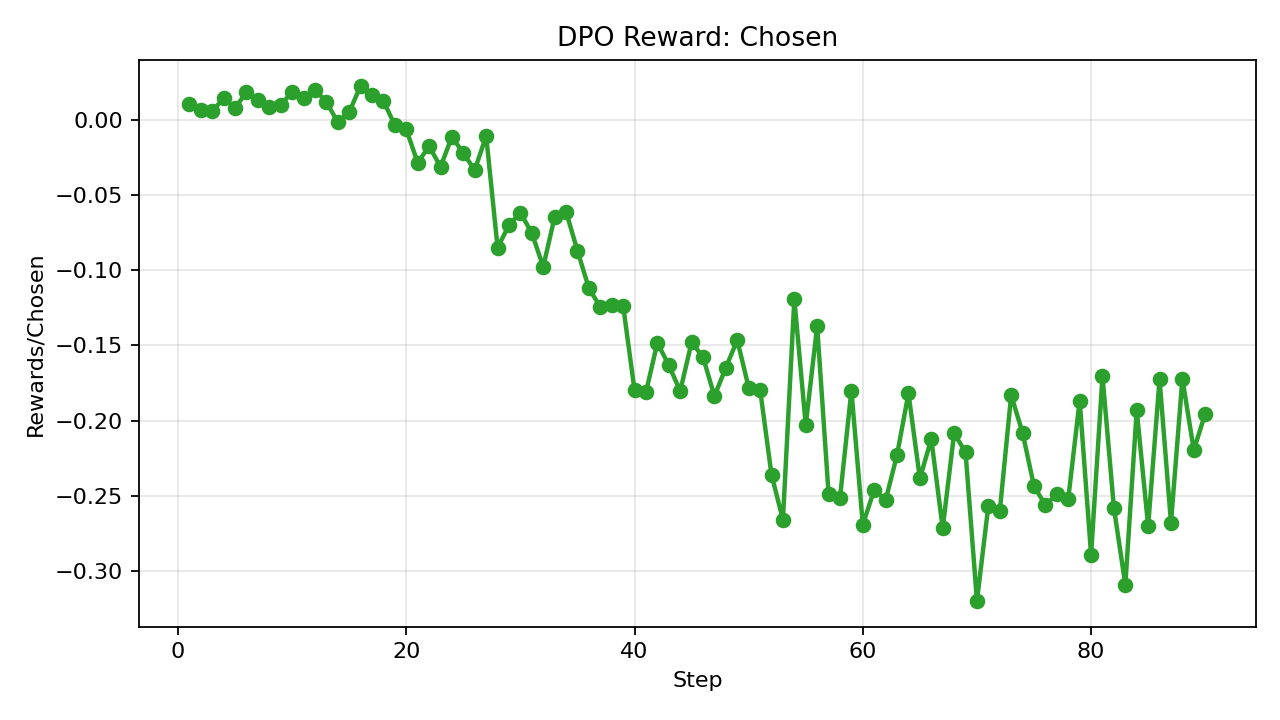

rewards_margins: /content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_rewards_margins_curve.png


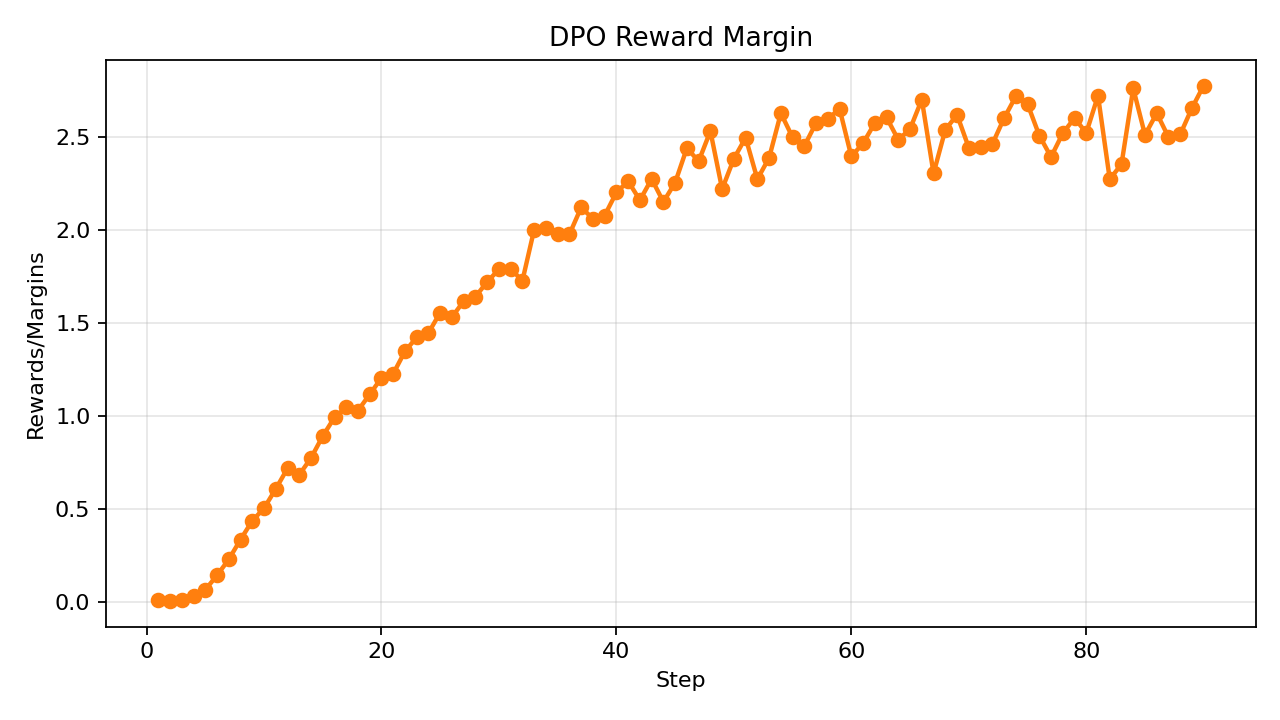

rewards_rejected: /content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_rewards_rejected_curve.png


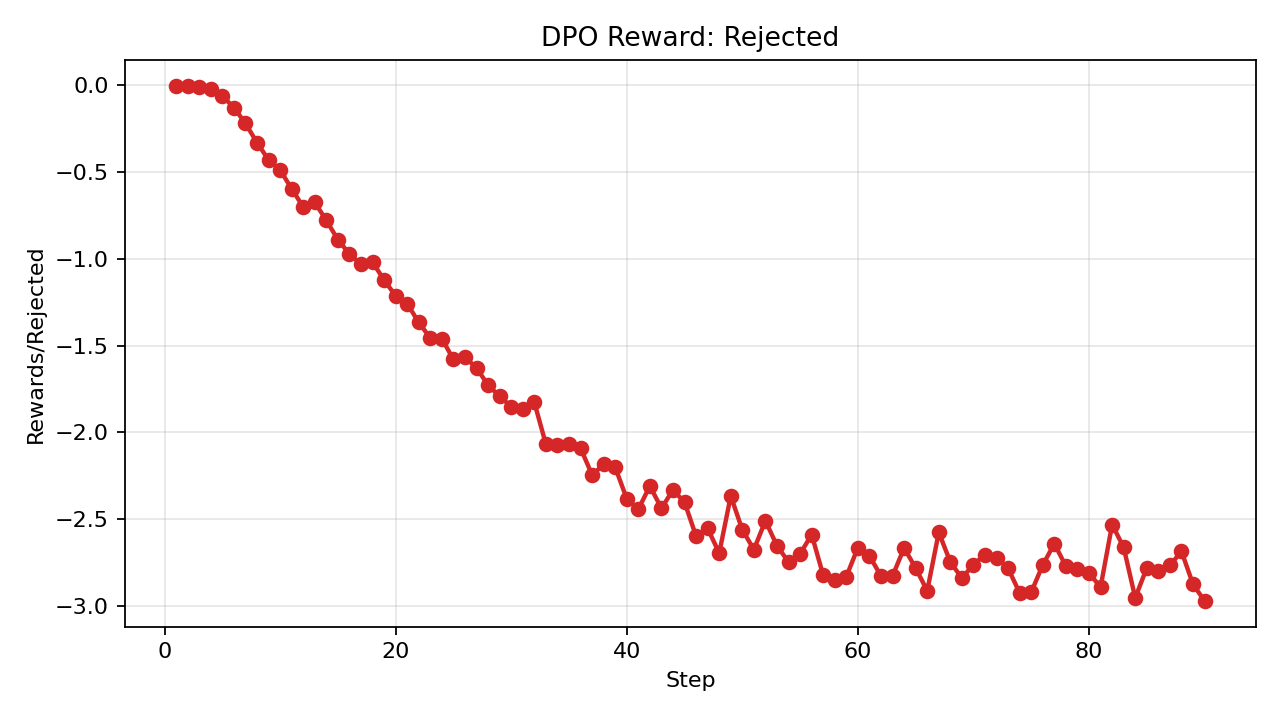

In [6]:
from IPython.display import Image, display
import sys

history_artifacts = dpo_summary.get('history_artifacts') or {}
loss_curve_path = history_artifacts.get('loss_curve_path') or dpo_summary.get('loss_curve_path')
eval_loss_curve_path = history_artifacts.get('eval_loss_curve_path') or dpo_summary.get('eval_loss_curve_path')
reward_plots = history_artifacts.get('extra_plot_paths') or dpo_summary.get('reward_plot_paths') or {}

needs_regen = False
if loss_curve_path and not Path(loss_curve_path).exists() and (dpo_history.get('raw_log_history') or []):
    needs_regen = True

if needs_regen:
    sys.path.insert(0, str(SOURCE_ROOT / 'src'))
    from json_ft.training_plots import PlotSpec, write_training_history_and_plots

    reward_spec_defaults = {
        'rewards/chosen': ('DPO Reward: Chosen', '#2ca02c'),
        'rewards/rejected': ('DPO Reward: Rejected', '#d62728'),
        'rewards/accuracies': ('DPO Reward Accuracy', '#9467bd'),
        'rewards/margins': ('DPO Reward Margin', '#ff7f0e'),
    }
    regenerated = write_training_history_and_plots(
        log_history=dpo_history.get('raw_log_history') or [],
        history_path=dpo_history_path,
        loss_curve_path=loss_curve_path,
        eval_loss_curve_path=eval_loss_curve_path,
        tracked_scalar_keys=list(reward_spec_defaults.keys()),
        extra_plot_specs=[
            PlotSpec(metric_key=metric_key, output_path=Path(reward_plots[metric_key]), title=title, color=color)
            for metric_key, (title, color) in reward_spec_defaults.items()
            if metric_key in reward_plots
        ],
        loss_curve_title='DPO Training Loss',
        eval_loss_curve_title='DPO Evaluation Loss',
    )
    history_artifacts.update(regenerated)
    dpo_summary['history_artifacts'] = history_artifacts
    loss_curve_path = history_artifacts.get('loss_curve_path') or loss_curve_path
    eval_loss_curve_path = history_artifacts.get('eval_loss_curve_path') or eval_loss_curve_path
    print('Regenerated missing DPO plot artifacts from raw trainer history.')

plot_candidates = [
    ('training_loss', loss_curve_path),
    ('eval_loss', eval_loss_curve_path),
]
for label, plot_path in reward_plots.items():
    plot_candidates.append((label, plot_path))

seen_paths = set()
rendered_any = False
for label, plot_path in plot_candidates:
    if not plot_path or plot_path in seen_paths:
        continue
    seen_paths.add(plot_path)
    path = Path(plot_path)
    if path.exists():
        rendered_any = True
        print(f'{label}: {path}')
        display(Image(filename=str(path)))
    else:
        print(f'Skipping missing optional plot for {label}: {path}')

if not rendered_any:
    print('No DPO plots were found. Re-run the training cell after syncing the latest source changes.')


In [4]:
SFT_PREDICTIONS = RUNTIME_ROOT / 'persistent' / 'reports' / f'{SFT_EVAL_RUN_NAME}_predictions.jsonl'
SFT_METRICS = RUNTIME_ROOT / 'persistent' / 'metrics' / f'{SFT_EVAL_RUN_NAME}_metrics.json'
DPO_PREDICTIONS = RUNTIME_ROOT / 'persistent' / 'reports' / f'{DPO_EVAL_RUN_NAME}_predictions.jsonl'
DPO_METRICS = RUNTIME_ROOT / 'persistent' / 'metrics' / f'{DPO_EVAL_RUN_NAME}_metrics.json'


In [9]:
!python {SOURCE_ROOT / 'scripts' / 'eval_model.py'} \
    --config {SOURCE_ROOT / 'configs' / 'eval.yaml'} \
    --run-name {SFT_EVAL_RUN_NAME} \
    --stage-label sft \
    --runtime-root {RUNTIME_ROOT} \
    --model-manifest {SFT_MANIFEST} \
    --dataset-path {EVAL_MANIFEST} \
    --eval-batch-size 64 \
    --prior-stage-predictions {BASELINE_PREDICTIONS} \
    --mirror-metrics-to-repo \
    --mirror-report-to-repo \
    --mirror-predictions-to-repo


Running model evaluation
Config: /content/drive/MyDrive/json-ft-source/configs/eval.yaml
Stage label: sft
Model: Qwen/Qwen2.5-1.5B-Instruct
Base model: Qwen/Qwen2.5-1.5B-Instruct
Adapter path: /content/drive/MyDrive/json-ft-runs/persistent/checkpoints/sft/sft-full-colab/adapter
Model manifest: /content/drive/MyDrive/json-ft-source/artifacts/checkpoints/sft-full-colab_adapter_manifest.json
Prior-stage predictions: /content/drive/MyDrive/json-ft-source/artifacts/reports/baseline-qwen2.5-1.5b_predictions.jsonl
Backend: local-transformers
Prompt source: messages
Dataset path: /content/drive/MyDrive/json-ft-source/data/manifests/support_tickets_eval_manifest.jsonl
Eval batch size: 64
is_colab=True
repo_root=/content/drive/MyDrive/json-ft-source
runtime_root=/content/drive/MyDrive/json-ft-runs
persistent_root=/content/drive/MyDrive/json-ft-runs/persistent
scratch_root=/content/drive/MyDrive/json-ft-runs/scratch
plots_dir=/content/drive/MyDrive/json-ft-runs/persistent/plots
stage=eval
run_nam

In [5]:
!python {SOURCE_ROOT / 'scripts' / 'eval_model.py'} \
    --config {SOURCE_ROOT / 'configs' / 'eval.yaml'} \
    --run-name {DPO_EVAL_RUN_NAME} \
    --stage-label dpo \
    --runtime-root {RUNTIME_ROOT} \
    --model-manifest {DPO_MANIFEST} \
    --dataset-path {EVAL_MANIFEST} \
    --eval-batch-size 192 \
    --prior-stage-predictions {SFT_PREDICTIONS} \
    --mirror-metrics-to-repo \
    --mirror-report-to-repo \
    --mirror-predictions-to-repo


Running model evaluation
Config: /content/drive/MyDrive/json-ft-source/configs/eval.yaml
Stage label: dpo
Model: Qwen/Qwen2.5-1.5B-Instruct
Base model: Qwen/Qwen2.5-1.5B-Instruct
Adapter path: /content/drive/MyDrive/json-ft-runs/persistent/checkpoints/dpo/dpo-full-colab/adapter
Model manifest: /content/drive/MyDrive/json-ft-source/artifacts/checkpoints/dpo-full-colab_dpo_manifest.json
Prior-stage predictions: /content/drive/MyDrive/json-ft-runs/persistent/reports/sft-full-colab_eval_predictions.jsonl
Backend: local-transformers
Prompt source: messages
Dataset path: /content/drive/MyDrive/json-ft-source/data/manifests/support_tickets_eval_manifest.jsonl
Eval batch size: 192
is_colab=True
repo_root=/content/drive/MyDrive/json-ft-source
runtime_root=/content/drive/MyDrive/json-ft-runs
persistent_root=/content/drive/MyDrive/json-ft-runs/persistent
scratch_root=/content/drive/MyDrive/json-ft-runs/scratch
plots_dir=/content/drive/MyDrive/json-ft-runs/persistent/plots
stage=eval
run_name=dpo-

In [6]:
!python {SOURCE_ROOT / 'scripts' / 'compare_stages.py'} \
    --run-name {COMPARISON_RUN_NAME} \
    --runtime-root {RUNTIME_ROOT} \
    --baseline-metrics {BASELINE_METRICS} \
    --baseline-predictions {BASELINE_PREDICTIONS} \
    --sft-metrics {SFT_METRICS} \
    --sft-predictions {SFT_PREDICTIONS} \
    --dpo-metrics {DPO_METRICS} \
    --dpo-predictions {DPO_PREDICTIONS} \
    --mirror-summary-to-repo \
    --mirror-report-to-repo


Comparison summary: /content/drive/MyDrive/json-ft-runs/persistent/metrics/dpo-full-colab_comparison_comparison_summary.json
Comparison report: /content/drive/MyDrive/json-ft-runs/persistent/reports/dpo-full-colab_comparison_comparison_report.md
Mirrored comparison summary: /content/drive/MyDrive/json-ft-source/artifacts/metrics/dpo-full-colab_comparison_comparison_summary.json
Mirrored comparison report: /content/drive/MyDrive/json-ft-source/artifacts/reports/dpo-full-colab_comparison_comparison_report.md


In [7]:
comparison_summary_path = RUNTIME_ROOT / 'persistent' / 'metrics' / f'{COMPARISON_RUN_NAME}_comparison_summary.json'
comparison_report_path = RUNTIME_ROOT / 'persistent' / 'reports' / f'{COMPARISON_RUN_NAME}_comparison_report.md'

comparison_summary = json.loads(comparison_summary_path.read_text(encoding='utf-8'))
comparison_report = comparison_report_path.read_text(encoding='utf-8')

comparison_summary


{'classification_basis': 'DPO relative to SFT',
 'deltas': {'dpo_vs_baseline': {'semantic': {'field_level_macro_f1': 0.3863019497542112,
    'field_level_micro_f1': 0.47003953011942146},
   'syntax': {'hallucinated_field_rate': -0.0032931726907630523,
    'json_recovery_rate': 0.0,
    'json_validity_rate': -0.0014457831325300763,
    'schema_validation_pass_rate': 0.010602409638554189}},
  'dpo_vs_sft': {'semantic': {'field_level_macro_f1': 0.03518699448265716,
    'field_level_micro_f1': 0.03958536879298924},
   'syntax': {'hallucinated_field_rate': 0.0,
    'json_recovery_rate': 0.0,
    'json_validity_rate': -0.0005622489959838939,
    'schema_validation_pass_rate': 0.14899598393574298}},
  'sft_vs_baseline': {'semantic': {'field_level_macro_f1': 0.35111495527155406,
    'field_level_micro_f1': 0.4304541613264322},
   'syntax': {'hallucinated_field_rate': -0.0032931726907630523,
    'json_recovery_rate': 0.0,
    'json_validity_rate': -0.0008835341365461824,
    'schema_validation_

In [8]:
print(comparison_report)


# Consolidated Comparison Report: dpo-full-colab_comparison

## Comparison Rules

- Syntax metrics are reported separately from semantic metrics.
- Semantic example ranking uses structured exact-match count plus `actions_requested` F1 as a row-level inspection aid.
- This row-level ranking is diagnostic only; the headline comparison remains the saved aggregate metrics.
- Row-level labels classify DPO relative to SFT as `syntax_gain_only`, `semantic_gain`, `semantic_regression`, or `mixed_result`.

## Stage Metrics

### Baseline

- Model: `Qwen/Qwen2.5-1.5B-Instruct`
- Base model: `n/a`
- Adapter path: `n/a`
- JSON validity rate: `0.9998`
- Schema validation pass rate: `0.9876`
- Hallucinated field rate: `0.0033`
- JSON recovery rate: `0.0000`
- Field-level micro F1: `0.3030`
- Field-level macro F1: `0.3008`
- Mean latency (ms): `10760.6296`

Exact match by categorical field:
- `issue_category`: `0.3022`
- `priority`: `0.1695`
- `product_area`: `0.2238`
- `sentiment`: `0.2991`
- `requir